In [1]:
# General imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Preprocessing imports
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Model fitting imports
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Model evaluation imports
from sklearn.metrics import confusion_matrix

## Data Preparation

In [2]:
singles = pd.read_hdf("singles_230801.h5")
flux_vals = pd.DataFrame(singles['FLUX'].to_list(), columns=[f'FLUX_{i}' for i in range(409)])
gt = singles["SPT"].str[0]
snrs = singles["J_SNR"]

df = pd.concat([gt, snrs, flux_vals], axis = 1)

In [3]:
SNR_FILTERING = False
AUGMENTATION = False #Monte-Carlo Sampling
IMPUTATION = None
NORMALIZATION_SCHEME = "brown dwarf"


# MODEL_TYPE = "random forest"
MODEL_TYPES = ["<class 'sklearn.tree._classes.DecisionTreeClassifier'>", 
               "<class 'sklearn.ensemble._forest.RandomForestClassifier'>", 
               "<class 'xgboost.sklearn.XGBClassifier'>"]
MODEL_CLASSIFIER = RandomForestClassifier(random_state = 42)
HYPERPARAM_TUNING = True

In [4]:
df.head()

,SPT,J_SNR,FLUX_0,FLUX_1,FLUX_2,FLUX_3,FLUX_4,FLUX_5,FLUX_6,FLUX_7,...,FLUX_399,FLUX_400,FLUX_401,FLUX_402,FLUX_403,FLUX_404,FLUX_405,FLUX_406,FLUX_407,FLUX_408
0,M,94.018303,1.966063e-10,2.113104e-10,2.215433e-10,2.269169e-10,2.322451e-10,2.340153e-10,2.264532e-10,2.183886e-10,...,5.567336e-11,5.740236e-11,5.390640e-11,5.251170e-11,5.513286e-11,5.493691e-11,5.639457e-11,5.432719e-11,5.391179e-11,5.327284e-11
1,M,386.537811,1.995077e-10,2.079591e-10,2.186989e-10,2.314572e-10,2.396579e-10,2.406922e-10,2.316760e-10,2.244714e-10,...,5.591276e-11,5.510603e-11,5.385560e-11,5.270259e-11,5.162297e-11,5.110227e-11,5.155890e-11,5.132251e-11,5.090229e-11,4.999533e-11
2,M,204.598099,1.976291e-10,2.058053e-10,2.110781e-10,2.208615e-10,2.230184e-10,2.221202e-10,2.202383e-10,2.149109e-10,...,6.030007e-11,5.930177e-11,5.825345e-11,5.708731e-11,5.563603e-11,5.537576e-11,5.549699e-11,5.508036e-11,5.505448e-11,5.516143e-11
3,M,91.589699,2.287852e-10,2.370316e-10,2.375884e-10,2.509034e-10,2.579899e-10,2.514759e-10,2.553226e-10,2.390649e-10,...,5.932869e-11,5.623817e-11,5.618077e-11,5.312362e-11,5.069763e-11,5.341758e-11,5.426651e-11,5.488549e-11,5.353450e-11,5.553981e-11
4,M,414.787994,2.061867e-10,2.142867e-10,2.222571e-10,2.337803e-10,2.400063e-10,2.379782e-10,2.291644e-10,2.187137e-10,...,5.953048e-11,5.892096e-11,5.671666e-11,5.483825e-11,5.366042e-11,5.395389e-11,5.447250e-11,5.488026e-11,5.409111e-11,5.382424e-11


In [5]:
class Preprocessing():
    def __init__(self, df, SNR_FILTERING, AUGMENTATION, IMPUTATION, NORMALIZATION_SCHEME):
        self.df = df
        self.SNR_FILTERING = SNR_FILTERING
        self.AUGMENTATION = AUGMENTATION
        self.IMPUTATION = IMPUTATION
        self.NORMALIZATION_SCHEME = NORMALIZATION_SCHEME


    def data_loader(self):
        if(self.SNR_FILTERING):
            self.df = self.df[self.df["J_SNR"] > 50].reset_index()

        if(self.AUGMENTATION):
            pass

        if(self.IMPUTATION == "mean"):
            pass
        elif(self.IMPUTATION == "zero"):
            pass
        else:
            self.df = self.df.dropna()

        if(self.NORMALIZATION_SCHEME == "general"):
            pass

        elif(self.NORMALIZATION_SCHEME == "brown dwarf"):
            # PER-ROW NORMALIZATION TO 1.25 micrometer FLUX VALUE
            X = self.df.drop(columns = ["SPT", "J_SNR"], axis = 1)
            X = X.apply(lambda row: row / row.iloc[88], axis=1)
            self.df = pd.concat([self.df["SPT"], self.df["J_SNR"], X], axis = 1)
        else:
            raise ValueError("Value of NORMALIZATION_SCHEME must be one of [\"general\", \"brown dwarf\"]")

        return self.df

In [6]:
class DimensionReduction():
    def __init__(self, X, DO_PCA):
        self.X = X
        self.DO_PCA = DO_PCA

    def PCA_feat(self):
        if(self.DO_PCA):
            scaler = MinMaxScaler()
            X_rescaled = scaler.fit_transform(self.X)
            pca = PCA(n_components = 0.97)
            pca.fit(X_rescaled)
            dim_reduced_X = pd.DataFrame(pca.transform(X_rescaled))
            return dim_reduced_X
        else:
            return self.X #returns X if DO_PCA is False.

In [7]:
# Preprocess data
preprocessor = Preprocessing(df, SNR_FILTERING, AUGMENTATION, IMPUTATION, NORMALIZATION_SCHEME)
preprocessed_df = preprocessor.data_loader()

# Get features and gt values after preprocessing
X = preprocessed_df.drop(columns = ["SPT", "J_SNR"], axis = 1)
y = preprocessed_df["SPT"]

# Perform PCA
dimension_reducer = DimensionReduction(X, True)
X = dimension_reducer.PCA_feat()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

## Model Fitting/Hyperparameter Tuning

In [8]:
class Model():
    def __init__(self, MODEL_TYPE, HYPERPARAM_TUNING, X_train, X_test, y_train, y_test):
        self.MODEL_CLASSIFIER = MODEL_CLASSIFIER
        if(str(type(self.MODEL_CLASSIFIER)) == MODEL_TYPES[0]):
            self.MODEL_TYPE = "decision tree"
        elif(str(type(self.MODEL_CLASSIFIER)) == MODEL_TYPES[1]):
            self.MODEL_TYPE = "random forest"
        elif(str(type(self.MODEL_CLASSIFIER)) == MODEL_TYPES[2]):
            self.MODEL_TYPE = "xgboost"
        else:
            # if self.MODEL_CLASSFIER not in MODEL_TYPES
            raise ValueError("Model must be one of [sklearn.tree.DecisionTreeClassifier, sklearn.ensemble.RandomForestClassifier, xgboost.XGBClassifier]")
        self.HYPERPARAM_TUNING = HYPERPARAM_TUNING
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        

    def fit(self):
        self.MODEL_CLASSIFIER.fit(self.X_train, self.y_train)
        preds = self.MODEL_CLASSIFIER.predict(self.X_test)
        return preds

    def hyperparam_tuning(self):
        if(self.HYPERPARAM_TUNING):
            if(self.MODEL_TYPE == "decision tree"):
                return self.fit()
            
            elif(self.MODEL_TYPE == "random forest"):
                rf_parameters = {'n_estimators': [50, 100, 200, 500],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 5, 10],
                 'max_depth' : [5, 7, 9, 10]}

                CV_rfc = GridSearchCV(estimator = self.MODEL_CLASSIFIER, param_grid = rf_parameters, scoring = 'accuracy', cv = 5)
                CV_rfc.fit(self.X_train, self.y_train)

                rfc_params = CV_rfc.best_params_

                print(rfc_params)

                classifier = RandomForestClassifier(**rfc_params, random_state = 42)
                classifier.fit(self.X_train, self.y_train)
                preds = classifier.predict(self.X_test)
                return preds

            elif(self.MODEL_TYPE == "xgboost"):
                return self.fit()

            else:
                raise ValueError("Supported model types are decision tree classifier, random forest classifier, or xgboost classifier.")

In [9]:
model = Model(MODEL_CLASSIFIER, HYPERPARAM_TUNING, X_train, X_test, y_train, y_test)
preds = model.fit()

## Model Evaluation

In [10]:
ACC = np.mean(preds == y_test)
print(f"CLASSIFIER ACCURACY: {ACC}")

tuned_preds = None
if(HYPERPARAM_TUNING):
    tuned_preds = model.hyperparam_tuning() #returns model.fit() if HYPERPARAM_TUNING is True and using dtree or xgboost (not implemented).
    ACC_tuned = np.mean(tuned_preds == y_test)
    print(f"CLASSIFIER TUNED ACCURACY: {ACC_tuned}")

CLASSIFIER ACCURACY: 0.9777777777777777
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
CLASSIFIER TUNED ACCURACY: 0.9777777777777777


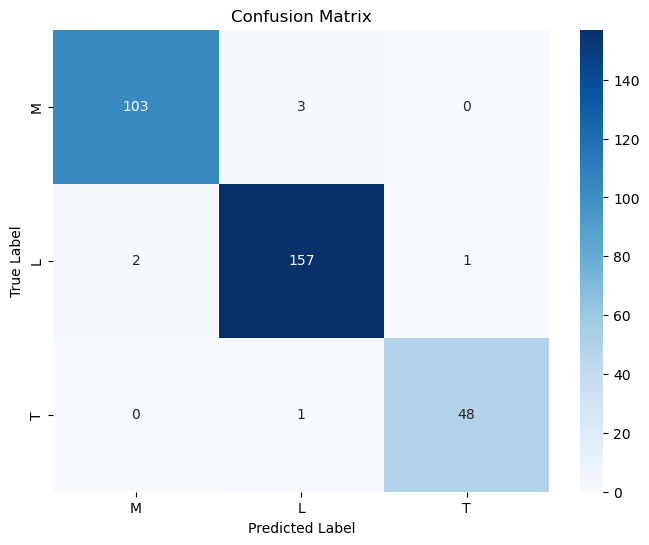

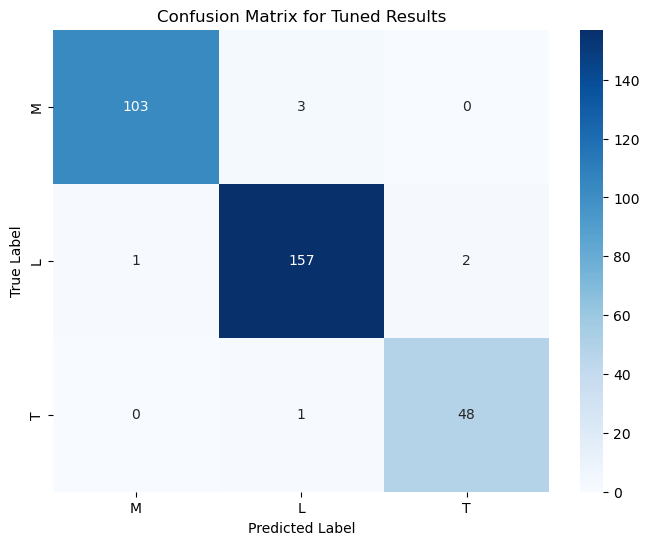

In [11]:
cm = confusion_matrix(y_test, preds, labels = ['M', 'L', 'T'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['M', 'L', 'T'],
            yticklabels=['M', 'L', 'T'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


if(HYPERPARAM_TUNING):
    cm = confusion_matrix(y_test, tuned_preds, labels = ['M', 'L', 'T'])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['M', 'L', 'T'],
                yticklabels=['M', 'L', 'T'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Tuned Results')
    plt.show()